In [1]:
import matplotlib.pyplot as plt
from ToyMaker import *

In [2]:
%%time
n1 = 3.5
n2 = 3.5
k1 = 4400 
k2 = 8080
γr1 = 1/5
γr2 = 50/251
β1 = 216/125
β2 = 216/125
kp1 = 50 
kp2 = 45
γp1 = 1/45
γp2 = 1/45

# Species
def p1(p1): return p1
def p2(p2): return p2

# Propensities
def s1 (p2) : return β1 * ((p2**n1) / (k1**n1 + p2**n1))
def s2 (r1) : return γr1 * r1
def s3 (p1) : return β2/(1 + (p1/k2)**n2)
def s4 (r2) : return γr2 * r2
def s5 (r1) : return kp1 * r1
def s6 (p1) : return γp1 * p1
def s7 (r2) : return kp2 * r2
def s8 (p2) : return γp2 * p2

# Species
species = {
            't':    0., 
            'cell': 0, 
            'size': birth_size(),
            p1:   0., 
            p2:   0., 
            'r1':   0., 
            'r2':   0.}

reactions = {
            s1: {'create':    ['r1']},
            s2: {'destroy':   ['r1']},
            s3: {'create':    ['r2']},
            s4: {'destroy':   ['r2']},
            s5: {'create':    ['p1']},
            s6: {'destroy':   ['p1']},
            s7: {'create':    ['p2']},
            s8: {'destroy':   ['p2']},
            'division': {'dilute' : ['r1', 'r2', 'p1' ,'p2']},
}

tmax = 800
sampling_time = 0.1
cell = 1
sim = Simulate_Division(species, reactions, tmax, sampling_time, cell)
cell_sim = Cell(species, reactions, tmax, sampling_time, cell=1, deterministic=False)

CPU times: user 44.3 s, sys: 0 ns, total: 44.3 s
Wall time: 44.3 s


Text(0.5, 0, 'Time (a.u)')

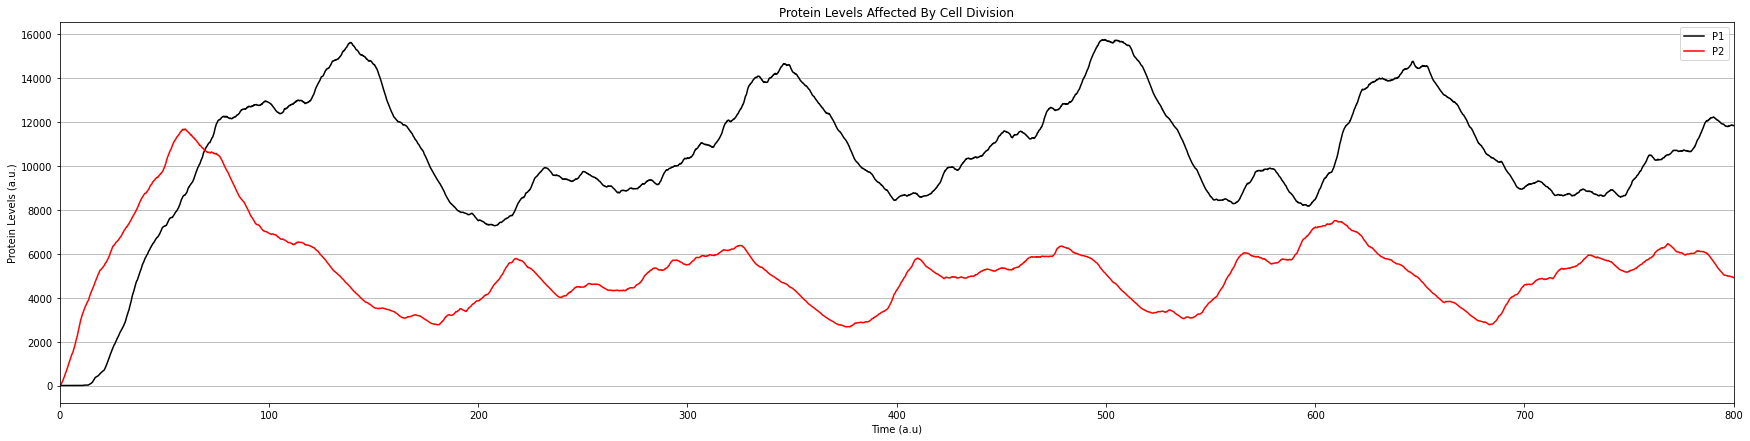

In [7]:
timearr = [cell_sim[i][0] for i in range(len(sim))]
protein = [cell_sim[i][3] for i in range(len(sim))]
protein2 = [cell_sim[i][4] for i in range(len(sim))]

fig, ax = plt.subplots(figsize=(30,7))
plt.plot(timearr, protein, 'k', label='P1')
plt.plot(timearr, protein2, 'r', label='P2')
plt.grid(True, axis='y')
plt.legend(loc='best')
plt.xlim(0, 800)
plt.title('Protein Levels Affected By Cell Division')
plt.ylabel('Protein Levels (a.u.)')
plt.xlabel('Time (a.u)')

In [8]:
timearr_s = [sim[i][0] for i in range(len(sim))]
size_s = [sim[i][2] for i in range(len(sim))]
protein_s = [sim[i][3] for i in range(len(sim))]
protein2_s = [sim[i][4] for i in range(len(sim))]

Text(0.5, 0, 'Time (a.u)')

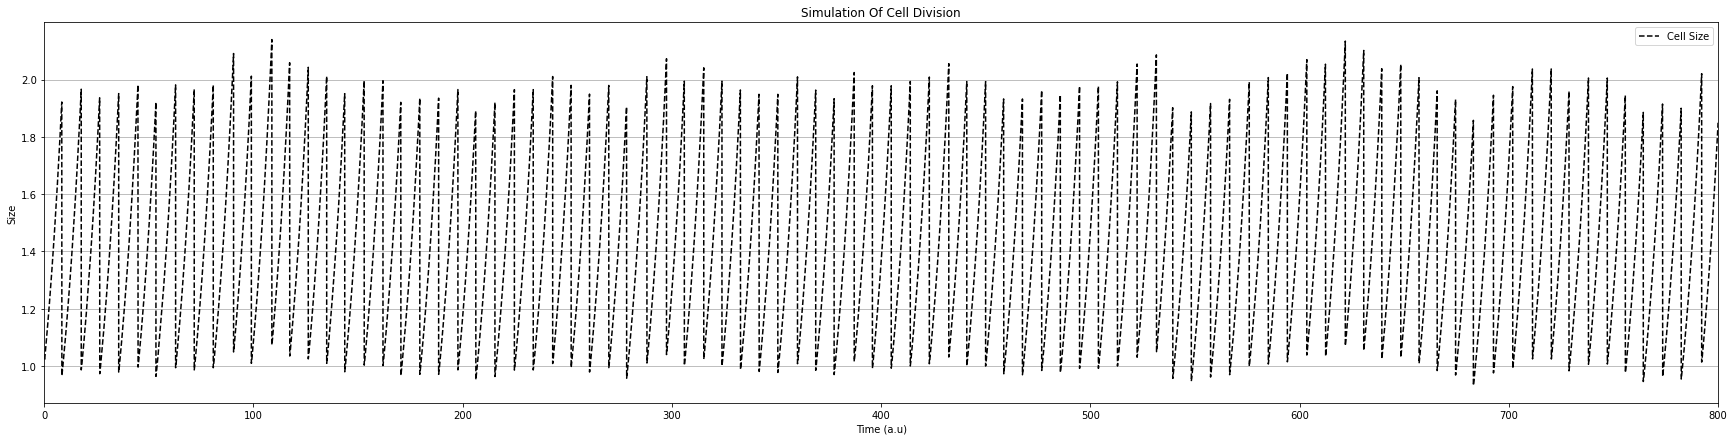

In [9]:
fig, ax = plt.subplots(figsize=(30,7))
plt.plot(timearr_s, size_s, '--', color='black', label='Cell Size')
plt.grid(True, axis='y')
plt.legend(loc='best')
plt.xlim(0, 800)
plt.title('Simulation Of Cell Division')
plt.ylabel('Size')
plt.xlabel('Time (a.u)')

Text(0.5, 0, 'Time (a.u)')

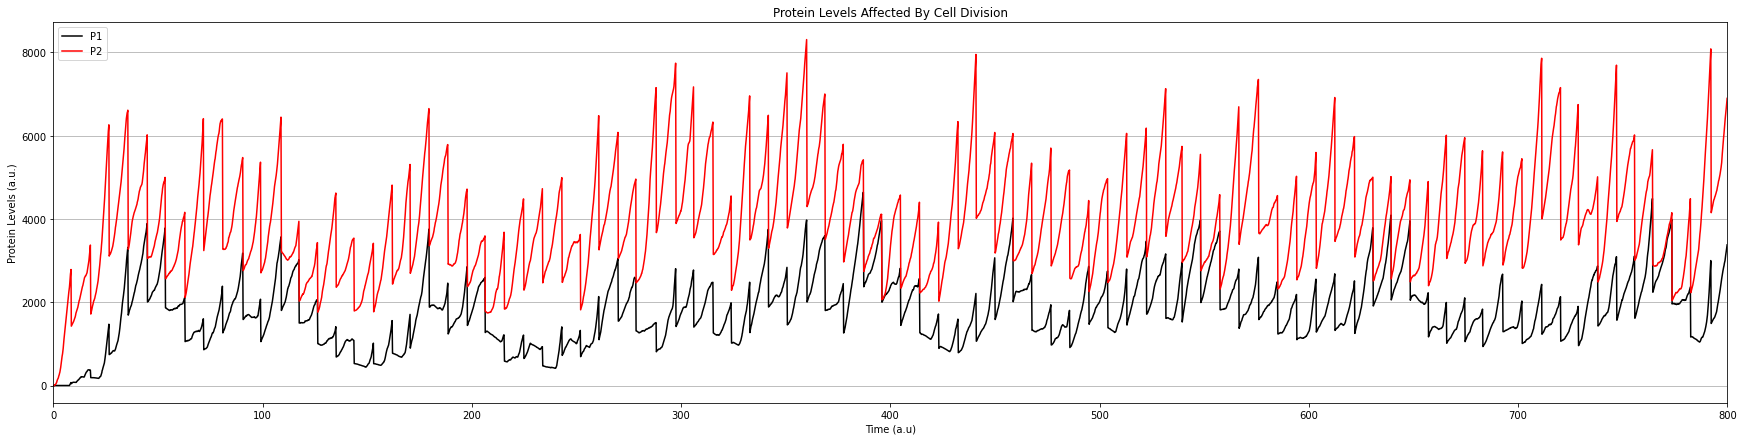

In [10]:
fig, ax = plt.subplots(figsize=(30,7))
plt.plot(timearr_s, protein_s, 'k', label='P1')
plt.plot(timearr_s, protein2_s, 'r', label='P2')
plt.grid(True, axis='y')
plt.legend(loc='best')
plt.xlim(0, 800)
plt.title('Protein Levels Affected By Cell Division')
plt.ylabel('Protein Levels (a.u.)')
plt.xlabel('Time (a.u)')